In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulate a realistic EV Battery Log
# 1000 data points (10 seconds of data at 100Hz)
time_ms = np.arange(0, 10000, 10)

# Simulating physics: Voltage dropping, Current steady, Temp rising
voltage = 400 - (time_ms * 0.001) + np.random.normal(0, 1.5, 1000) 
current = 150 + np.random.normal(0, 3, 1000) 
temperature = 25 + (time_ms * 0.002) 

# Introduce a "Sensor Dropout" (Missing data for 20 samples)
voltage[500:520] = np.nan 

# 2. Create the Pandas DataFrame
df_raw = pd.DataFrame({
    'Time_ms': time_ms,
    'Voltage_V': voltage,
    'Current_A': current,
    'Temp_C': temperature
})

# 3. Save it to a CSV to simulate receiving a file from the test bench
df_raw.to_csv('ev_battery_log.csv', index=False)
print("✅ ev_battery_log.csv created on your hard drive!")

In [4]:
# Load the file
df = pd.read_csv('ev_battery_log.csv')

# df.head() shows the first 5 rows. df.tail() shows the last 5.
print("--- Quick Look at the Data ---")
print(df.head())

# df.info() tells you the data types and if anything is missing
print("\n--- System Diagnostics ---")
df.info()

# df.isna().sum() specifically counts the missing/broken values
print("\n--- Locating Sensor Dropouts ---")
print(df.isna().sum())

--- Quick Look at the Data ---
   Time_ms   Voltage_V   Current_A  Temp_C
0        0  402.952921  148.991333   25.00
1       10  399.671923  154.974647   25.02
2       20  400.234922  146.780903   25.04
3       30  400.389843  150.692291   25.06
4       40  400.542757  147.142513   25.08

--- System Diagnostics ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Time_ms    1000 non-null   int64  
 1   Voltage_V  980 non-null    float64
 2   Current_A  1000 non-null   float64
 3   Temp_C     1000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 31.4 KB

--- Locating Sensor Dropouts ---
Time_ms       0
Voltage_V    20
Current_A     0
Temp_C        0
dtype: int64


Missing Voltage Values after fix: 0

Found 249 samples where Temp > 40C.


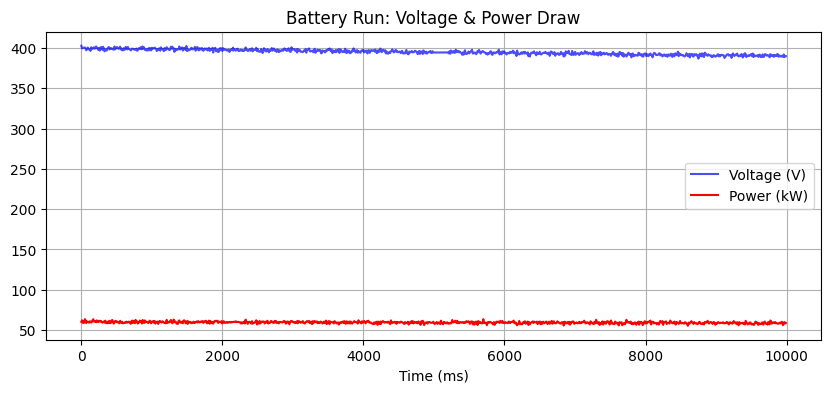

In [6]:
# 1. CLEANING: Interpolate the missing voltage data (draws a line between the gap)
df['Voltage_V'] = df['Voltage_V'].interpolate(method='linear')

# Verify the fix
print(f"Missing Voltage Values after fix: {df['Voltage_V'].isna().sum()}")

# 2. FEATURE ENGINEERING: Calculate Power (P = V * I)
# We calculate a massive array of math instantly without loops
df['Power_kW'] = (df['Voltage_V'] * df['Current_A']) / 1000

# 3. FILTERING: Let's isolate the data where the battery got too hot (> 40C)
df_hot = df[df['Temp_C'] > 40.0]
print(f"\nFound {len(df_hot)} samples where Temp > 40C.")

# 4. VISUALIZATION
plt.figure(figsize=(10, 4))
plt.plot(df['Time_ms'], df['Voltage_V'], label="Voltage (V)", color='blue', alpha=0.7)
plt.plot(df['Time_ms'], df['Power_kW'], label="Power (kW)", color='red')

plt.title("Battery Run: Voltage & Power Draw")
plt.xlabel("Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

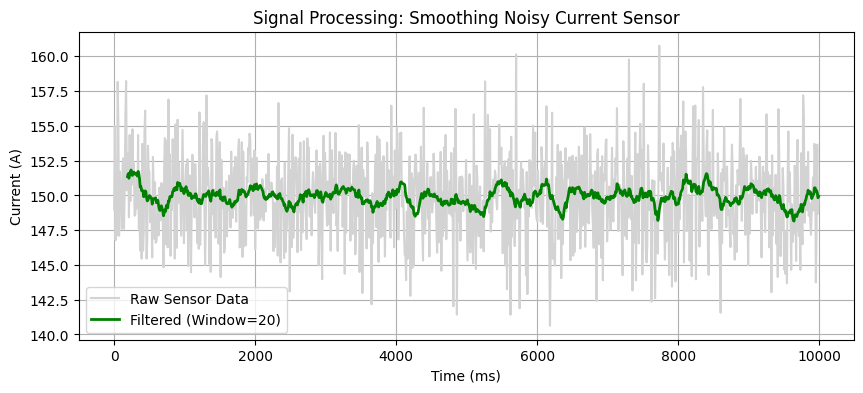

In [7]:
# 1. Apply a Simple Moving Average (SMA) 
# A window of 20 means it averages the last 20 samples (200ms) to smooth the line
df['Current_Filtered'] = df['Current_A'].rolling(window=20).mean()

# 2. VISUALIZE THE FILTER
plt.figure(figsize=(10, 4))

# Plot the raw, noisy data in the background
plt.plot(df['Time_ms'], df['Current_A'], label="Raw Sensor Data", color='lightgray')

# Plot the smoothed data on top
plt.plot(df['Time_ms'], df['Current_Filtered'], label="Filtered (Window=20)", color='green', linewidth=2)

plt.title("Signal Processing: Smoothing Noisy Current Sensor")
plt.xlabel("Time (ms)")
plt.ylabel("Current (A)")
plt.legend()
plt.grid(True)
plt.show()